Row sums: [0.28131033 0.3295295  0.38916017]
Predicted Probabilities: 
 [[0.0277276  0.18538383 0.0681989 ]
 [0.02386537 0.22642832 0.07923582]
 [0.02054111 0.27656017 0.09205888]]
Categorical Cross-Entropy Loss: 2.601993529806192
Gradient of Loss: [[-0.04651307  0.00260489 -0.05429432]
 [-0.07744193 -0.0077827  -0.07964453]]
Adjusted Learning Rate: 0.08333333333333334


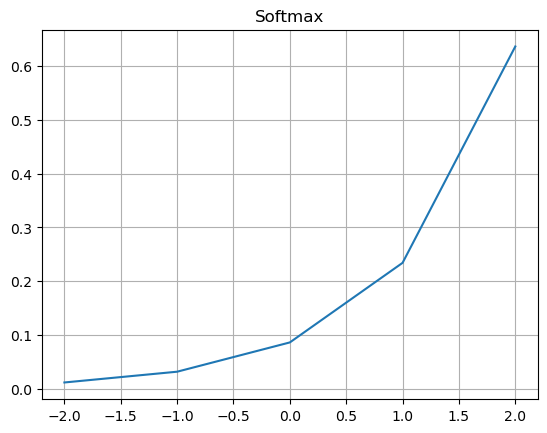

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    x = np.array(x)
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

def categorical_cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
    return -np.sum(y_true * np.log(y_pred)) / y_true.shape[0]

def categorical_cross_entropy_derivative(y_true, y_pred):
    return y_pred - y_true

def forward_pass(X, weights):
    y_pred = softmax(np.dot(X, weights))
    print("Row sums:", np.sum(y_pred, axis=1))
    return y_pred

def backward_pass(X, y_true, y_pred, lr):
    grad = categorical_cross_entropy_derivative(y_true, y_pred)
    dW = np.dot(X.T, grad) / X.shape[0]
    return dW * lr

# Data
X = np.array([[1.0, 2.0], [1.5, 2.5], [2.0, 3.0]])
weights = np.array([[0.2, -0.3, 0.5], [-0.5, 0.7, -0.2]])
y_true = np.array([[0,1,0], [1,0,0], [0,0,1]])

# Forward + loss
y_pred = forward_pass(X, weights)
loss = categorical_cross_entropy(y_true, y_pred)

# Backward
update = backward_pass(X, y_true, y_pred, 0.1)

# Outputs (as required)
print("Predicted Probabilities: \n", y_pred)
print("Categorical Cross-Entropy Loss:", loss)
print("Gradient of Loss:", update)

# Learning rate
print("Adjusted Learning Rate:", adjust_learning_rate(0.1, 20))

# Softmax visualization
x_vals = np.array([-2, -1, 0, 1, 2])
plt.plot(x_vals, softmax(x_vals))
plt.title("Softmax")
plt.grid()
plt.show()